In [1]:
from IPython.display import clear_output

# Content

In this notebook we will finetune a transformer network taken from huggingface, using huggingface's Trainer API

we will train facebook's mbart model to create a two way chinese to urdu language translator.

The reason for chosing mbart as the source model is because it has already seen a lot of languages's data(50 in our case) during pre-training

you can find more information about mbart on [hugging face](https://huggingface.co/facebook/mbart-large-50)

In [2]:
# %pip install gdown
# %pip install evaluate
# %pip install pandas
# %pip install sentencepiece
# %pip install accelerator
# %pip install protobuf==3.20.3
# %pip install matplotlib
# %pip install transformers datasets

# %pip install --disable-pip-version-check \
#     torch \
#     torchdata --quiet

# %pip install tqdm

clear_output()

In [3]:
# %pip install datasets
# %pip install transformers[torch]  # [torch] because Trainer API with torch needs accelerator installed. This takes care of that. Might need a restart of the session
# %pip install gdown==4.5
# %pip install evaluate
# %pip install rouge_score
# 
# clear_output()

In [2]:
import math
from datasets import Dataset
from transformers import GenerationConfig, TrainingArguments, Trainer, TrainerCallback
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast
import torch
import pandas as pd
import evaluate
from tqdm import tqdm
import json

import matplotlib.pyplot as plt

import random

2025-03-15 21:58:39.090553: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-15 21:58:39.858676: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742065120.145646   44474 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742065120.230541   44474 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-15 21:58:40.893993: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## Downloading the data

In [3]:
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("Abdulmohsena/Classic-Arabic-English-Language-Pairs")


In [4]:
# Explore the dataset
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['en', 'ar'],
        num_rows: 20364
    })
})


In [5]:
random.seed(7)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [6]:
from sklearn.model_selection import train_test_split
# Convert to pandas DataFrames
train_data = pd.DataFrame(dataset['train'])

# First split into train and test
train_data_full, test_data = train_test_split(train_data, test_size=0.2, random_state=42)

# Then limit each to 4000 samples
train_data = train_data_full.head(4000)  # Take the first 4000 samples
test_data = test_data.head(4000)  # Take the first 4000 samples

print(f"Training data shape: {train_data.shape}")
print(f"Testing data shape: {test_data.shape}")



Training data shape: (4000, 2)
Testing data shape: (4000, 2)


In [7]:
# Sample of the data
train_data.head()

,en,ar
7792,"The greater the burden, the more you must be c...",وبقدر عظمها يجب التكليف من الله عليها؛ فبقدر م...
10285,"Before that, when he was the emir of the city,...",فأما قبلها، وهو أمير المدينة، فكان يسمع الغناء...
586,"Then the people are called to prayer, and thei...",ثم يؤذن للناس، وتؤخذ رقاعهم فينظر فيها.
10493,Have I not informed you? The believer is the o...,ألا أخبركم بالمؤمن من أمنه الناس على أموالهم و...
10590,These muscles should be less fleshy at the sec...,ويجب أن تكون هذه العضلات عند المقاطع أقل لحمية...


In [8]:
train_dataset = Dataset.from_pandas(train_data, split='train')
test_dataset = Dataset.from_pandas(test_data, split='test')

## Prepare the model and tokenizers

In [9]:
model_name='facebook/mbart-large-50'

model = MBartForConditionalGeneration.from_pretrained(model_name)
tokenizer1 = MBart50TokenizerFast.from_pretrained(model_name, src_lang="en_XX", tgt_lang="ar_AR")
tokenizer2 = MBart50TokenizerFast.from_pretrained(model_name, src_lang="ar_AR", tgt_lang="en_XX")

In [10]:
def tokenize_function(rows):
    src_language = 'en'
    tgt_language = 'ar'

    # Randomly swap source and target language for data augmentation
    if random.randint(0, 1) == 1:
        src_language, tgt_language = tgt_language, src_language

    src_tokenizer, tgt_tokenizer = [get_apt_tokenizer(language) for language in (src_language, tgt_language)]

    start_prompt = f''
    end_prompt = f''
    prompt = [start_prompt + row + end_prompt for row in rows[src_language]]
    rows['src_language'] = [src_language] * len(rows[src_language])
    rows['prompt'] = prompt
    encoding = src_tokenizer(prompt, padding="max_length", truncation=True, return_tensors="pt", max_length=256)
    rows['input_ids'], rows['attention_mask'] = encoding.input_ids, encoding.attention_mask
    rows['labels'] = tgt_tokenizer(rows[tgt_language], padding="max_length", truncation=True, return_tensors="pt", max_length=256).input_ids

    return rows

def get_apt_tokenizer(src_language):
    if src_language.lower() == 'en':
        return tokenizer1  # English tokenizer
    elif src_language.lower() == 'ar':
        return tokenizer2  # Arabic tokenizer
    else:
        raise ValueError('Invalid Language')

In [11]:
tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

## Check to see tokenizer is working correctly by encoding and decoding

In [12]:
idx = 2501
row = tokenized_test_dataset[idx]
tokenizer = get_apt_tokenizer(row['src_language'])

print(f'{row["src_language"]=}')
print(f'English: {row["en"]}')
print(f'Arabic: {row["ar"]}')
print(f'Input decoded: {tokenizer.decode(row["input_ids"], skip_special_tokens=True)}')
print(f'Label decoded: {tokenizer.decode(row["labels"], skip_special_tokens=True)}')

row["src_language"]='ar'
English: The shepherd was happy that he was slow to get him back, until he thought he had taken what he needed from the bridle, then he stood up and said: O shepherd, bring my horse to me, for some of the wind has entered my eyes, and I am unable to open them.
Arabic: وجعل الراعي يفرح بإبطائه عنه، حتى إذا ظن أنه قد أخذ حاجته من اللجام، قام، فقال: يا راعي، قد إلي فرسي، فإنه قد دخل في عيني مما في هذه الريح، فما اقدر على فتحهما.
Input decoded: وجعل الراعي يفرح بإبطائه عنه، حتى إذا ظن أنه قد أخذ حاجته من اللجام، قام، فقال: يا راعي، قد إلي فرسي، فإنه قد دخل في عيني مما في هذه الريح، فما اقدر على فتحهما.
Label decoded: The shepherd was happy that he was slow to get him back, until he thought he had taken what he needed from the bridle, then he stood up and said: O shepherd, bring my horse to me, for some of the wind has entered my eyes, and I am unable to open them.


In [13]:
tokenized_train_dataset.shape

(4000, 8)

In [14]:
tokenized_train_dataset = tokenized_train_dataset.shuffle(seed=13)
tokenized_test_dataset = tokenized_test_dataset.shuffle(seed=13)

In [15]:
print(tokenized_train_dataset.shape)
tokenized_train_dataset

(4000, 8)


Dataset({
    features: ['en', 'ar', '__index_level_0__', 'src_language', 'prompt', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 4000
})

## Pre-trained model

In [16]:
sample_english = "Strengthening the rule of law in corporate culture to improve the legal management capabilities of executives."
with torch.no_grad():
    res = model.generate(**tokenizer1(sample_english, return_tensors='pt'))
tokenizer1.batch_decode(res)[0]

'</s><s> Strengthening the rule of law in corporate culture to improve the legal management capabilities of executives.</s>'

In [17]:
sample_arabic = "تعزيز ثقافة سيادة القانون في الشركات لتحسين قدرات الإدارة القانونية للمديرين التنفيذيين."
with torch.no_grad():
    res = model.generate(**tokenizer2(sample_arabic, return_tensors='pt'))
tokenizer2.batch_decode(res)[0]

'</s><s> تعزيز ثقافة سيادة القانون في الشركات لتحسين قدرات الإدارة القانونية للمديرين التنفيذيين.</s>'

## Training the model

In [18]:
# Create a list to store losses
train_losses = []
val_losses = []

# Custom callback to store losses every 500 steps
class CustomCallback(TrainerCallback):

    def on_log(self, args, state, control, **kwargs):
        # Check if training loss is available in the logs
        if "train_loss" in state.log_history:
            train_loss = state.log_history["train_loss"]
            train_losses.append(train_loss)

        # Check if validation loss is available in the logs
        if "eval_loss" in state.log_history:
            val_loss = state.log_history["eval_loss"]
            val_losses.append(val_loss)

output_dir = f'./checkpoints/mbart-large-translator-full-run'  # full for full fine tune

training_args = TrainingArguments(
    output_dir=output_dir,
    # per_device_train_batch_size=4,
    auto_find_batch_size=True,
    learning_rate=5e-5,
    num_train_epochs=2,
    eval_steps=500,
    save_steps=5000,
    logging_steps=500,
    evaluation_strategy="steps",
    save_strategy="steps",
    # load_best_model_at_end=True,
    warmup_steps=100
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    # compute_metrics=lambda x: 1
    callbacks=[CustomCallback()]
)

/home/ali/.virtualenvs/PyTorchENV/lib/python3.10/site-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [39]:
trainer.train()

Step,Training Loss,Validation Loss
500,1.788400,0.370768
1000,0.582300,0.349421


Step,Training Loss,Validation Loss
500,1.788400,0.370768
1000,0.582300,0.349421


TrainOutput(global_step=1000, training_loss=1.185332977294922, metrics={'train_runtime': 2989.5983, 'train_samples_per_second': 2.676, 'train_steps_per_second': 0.334, 'total_flos': 4334259535872000.0, 'train_loss': 1.185332977294922, 'epoch': 2.0})

In [40]:
model.save_pretrained('mbart_2ep_full_finetuned_bidir')

In [19]:
sample_english = "Strengthen enterprises"
with torch.no_grad():
    encoding = tokenizer1(sample_english, return_tensors='pt')
    input_ids, attn_mask = encoding.input_ids.to(model.device), encoding.attention_mask.to(model.device)
    # Add forced_bos_token_id for Arabic
    res = model.generate(
        input_ids=input_ids, 
        attention_mask=attn_mask,
        forced_bos_token_id=tokenizer1.lang_code_to_id["ar_AR"]
    )
print(tokenizer1.batch_decode(res)[0])

</s>ar_AR<s> Strengthen enterprises - Strengthen enterprises</s>


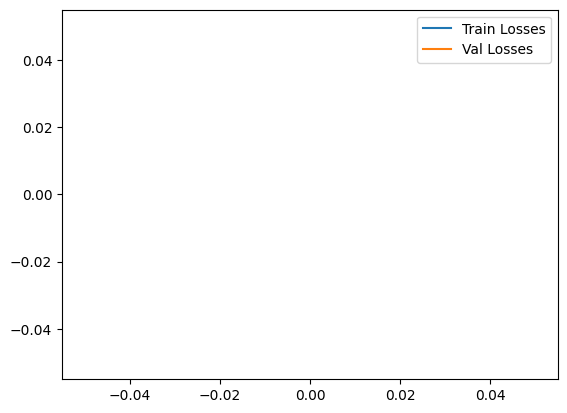

In [43]:
plt.plot(train_losses, label='Train Losses')
plt.plot(val_losses, label='Val Losses')

plt.legend()
plt.show()

## Evaluating the results

In [20]:
untrained_model = MBartForConditionalGeneration.from_pretrained(model_name)

In [21]:
bleu = evaluate.load('bleu')

In [22]:
en_to_ar_data = test_data.sample(frac=0.5, random_state=123)
ar_to_en_data = test_data.loc[test_data.index.difference(en_to_ar_data.index)]

In [ ]:
batch_size = 16

# Rename your dataframe variable to match your dataset
en_to_ar_data = train_data  # Or whatever your dataframe is called

num_batches = int(math.ceil(len(en_to_ar_data)/batch_size))

all_untrained_model_outputs = []
all_trained_model_outputs = []

for i in tqdm(range(num_batches)):
    batch_start = i*batch_size
    batch_end = batch_start + batch_size

    batch_df = en_to_ar_data.iloc[batch_start:] if i == num_batches - 1 else en_to_ar_data.iloc[batch_start: batch_end]

    # Update to use 'en' column instead of 'chinese'
    prompts = [f'{english}' for english in batch_df['en']]

    with torch.no_grad():
        encodings = tokenizer1(prompts, return_tensors="pt", padding="max_length", truncation=True, max_length=256)

        input_ids = encodings.input_ids.to(device)
        attention_mask = encodings.attention_mask.to(device)

        model_outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            generation_config=GenerationConfig(max_new_tokens=256)
        )
        model_text_output = tokenizer1.batch_decode(model_outputs, skip_special_tokens=True)
        all_untrained_model_outputs.extend(model_text_output)

        trained_model_outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            generation_config=GenerationConfig(max_new_tokens=256)
        )
        trained_model_text_output = tokenizer1.batch_decode(trained_model_outputs, skip_special_tokens=True)
        all_trained_model_outputs.extend(trained_model_text_output)

  6%|▋         | 16/250 [00:35<08:31,  2.18s/it]

In [ ]:
en_to_ar_data['trained_model_arabic'] = all_trained_model_outputs
en_to_ar_data['untrained_model_arabic'] = all_untrained_model_outputs

In [ ]:
original_bleu = bleu.compute(
    predictions=en_to_ar_data['untrained_model_arabic'],
    references=en_to_ar_data['ar'],
)

trained_bleu = bleu.compute(
    predictions=en_to_ar_data['trained_model_arabic'],
    references=en_to_ar_data['ar'],
)

In [ ]:
print('English to Arabic')
print('Original model:')
print(json.dumps(original_bleu, indent=2))
print('Trained model:')
print(json.dumps(trained_bleu, indent=2))